# Dimension Reduction

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Standardise the Data

In [55]:
equity_returns = pd.read_csv("../data/raw/equity_returns.csv", index_col=0, parse_dates=True)

In [56]:
scaler = StandardScaler()

scaled_equity_returns = pd.DataFrame(
    scaler.fit_transform(equity_returns),
    index=equity_returns.index,
    columns=equity_returns.columns
)

### Fit PCA

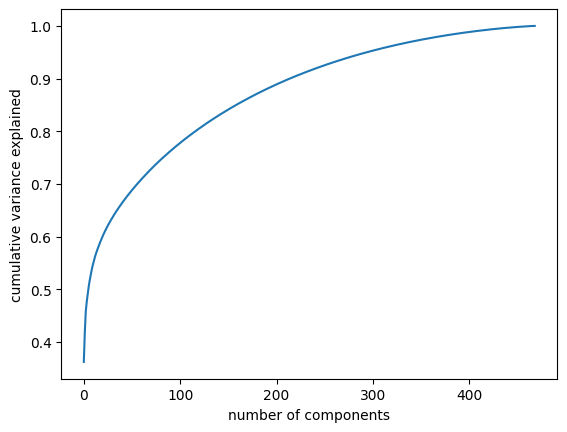

In [57]:
pca = PCA()
pca.fit(scaled_equity_returns)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("number of components")
plt.ylabel("cumulative variance explained")
plt.show()

In [58]:
np.cumsum(pca.explained_variance_ratio_[:11])

array([0.36188176, 0.41657777, 0.45700988, 0.47581265, 0.49067349,
       0.50397922, 0.51571337, 0.52572384, 0.5350666 , 0.54354468,
       0.55072119])

In [59]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(scaled_equity_returns)
X_reconstructed = pca.inverse_transform(X_pca)

residuals = equity_returns - X_reconstructed

In [60]:
residuals_df = pd.DataFrame(
    residuals,
    index=equity_returns.index,
    columns=equity_returns.columns
)

residuals_df.to_csv("../data/manipulated/residuals.csv")

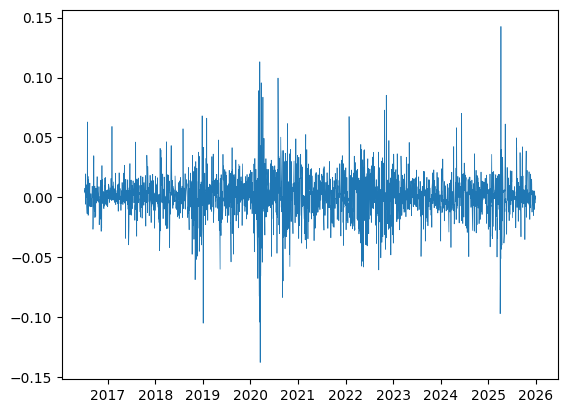

In [61]:
import matplotlib.pyplot as plt

plt.plot(equity_returns.index, equity_returns['AAPL'], linewidth=0.5)

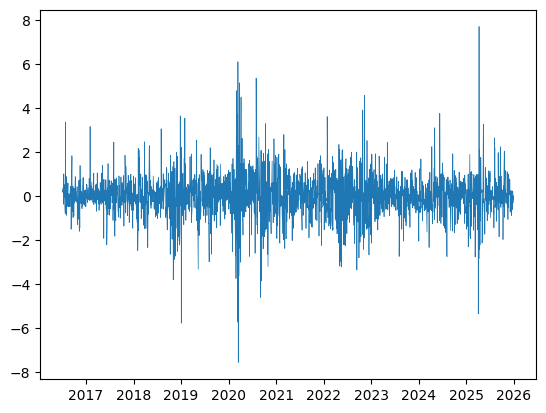

In [62]:
plt.plot(equity_returns.index, scaled_equity_returns['AAPL'], linewidth=0.5)

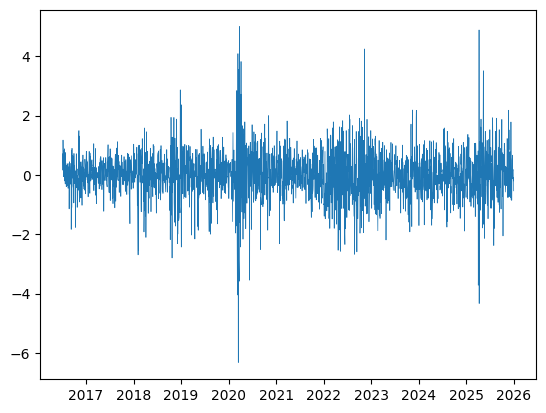

In [63]:
plt.plot(equity_returns.index, X_reconstructed[:, 0], linewidth=0.5)

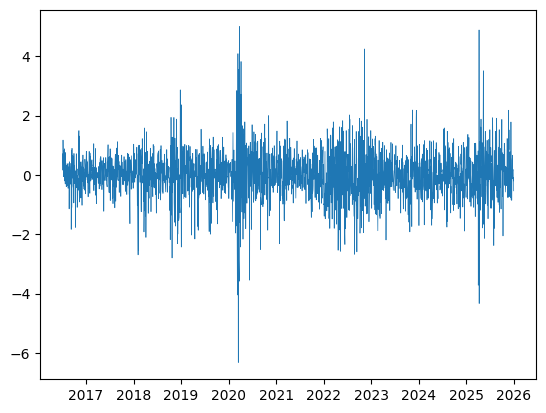

In [64]:
plt.plot(equity_returns.index, X_reconstructed[:, 0], linewidth=0.5)